#📌 Extracción

In [2]:
import pandas as pd
import requests

# URL directa al JSON
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Extraemos la data haciendo una petición a la API simulada
respuesta = requests.get(url)
datos_json = respuesta.json()

# Aplanamos los datos anidados (ETL - Extracción)
df_bruto = pd.json_normalize(datos_json)

# Verificamos las primeras líneas y cómo quedaron las columnas
display(df_bruto.head(3))

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


#🔧 Transformación

In [3]:
import numpy as np

# 1. Limpieza de nombres de columnas
nuevos_nombres = {
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'SeniorCitizen',
    'customer.Partner': 'Partner',
    'customer.Dependents': 'Dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'PhoneService',
    'phone.MultipleLines': 'MultipleLines',
    'internet.InternetService': 'InternetService',
    'internet.OnlineSecurity': 'OnlineSecurity',
    'internet.OnlineBackup': 'OnlineBackup',
    'internet.DeviceProtection': 'DeviceProtection',
    'internet.TechSupport': 'TechSupport',
    'internet.StreamingTV': 'StreamingTV',
    'internet.StreamingMovies': 'StreamingMovies',
    'account.Contract': 'Contract',
    'account.PaperlessBilling': 'PaperlessBilling',
    'account.PaymentMethod': 'PaymentMethod',
    'account.Charges.Monthly': 'MonthlyCharges',
    'account.Charges.Total': 'TotalCharges'
}
df_limpio = df_bruto.rename(columns=nuevos_nombres)

# 2. Transformar 'TotalCharges' de texto a numérico
df_limpio['TotalCharges'] = pd.to_numeric(df_limpio['TotalCharges'], errors='coerce')
df_limpio['TotalCharges'] = df_limpio['TotalCharges'].fillna(0) # Clientes nuevos sin cobros aún

# 3. Tratar datos faltantes en nuestra variable objetivo (Churn)
df_limpio['Churn'] = df_limpio['Churn'].replace(r'^\s*$', np.nan, regex=True)
df_limpio = df_limpio.dropna(subset=['Churn']).reset_index(drop=True)

# Revisamos que todo esté en el tipo de dato correcto
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


#📊 Carga y análisis

/tmp/ipykernel_1229/1810094071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
/tmp/ipykernel_1229/1810094071.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Churn', y='MonthlyCharges', palette='Set2', ax=axes[2])


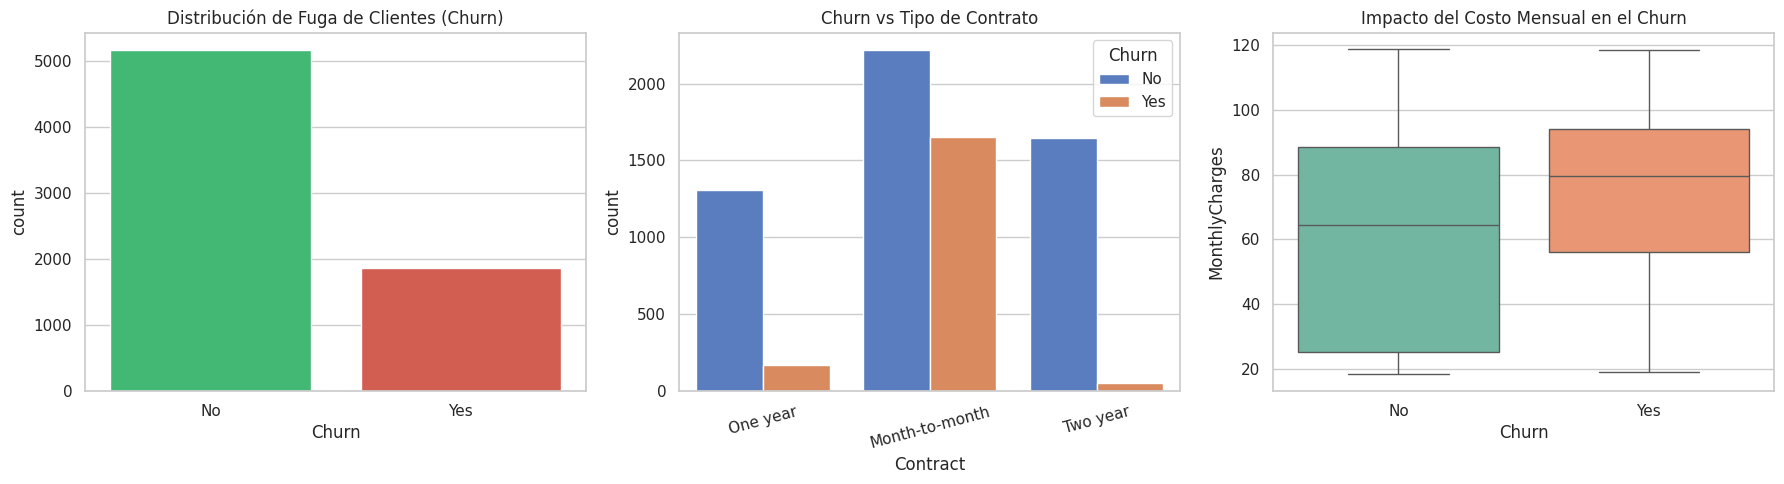

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo para gráficos de nivel corporativo
sns.set_theme(style="whitegrid")

# Figura con 3 gráficos clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Desbalanceo del Churn
sns.countplot(data=df_limpio, x='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribución de Fuga de Clientes (Churn)')

# Gráfico 2: Churn según Tipo de Contrato
sns.countplot(data=df_limpio, x='Contract', hue='Churn', palette='muted', ax=axes[1])
axes[1].set_title('Churn vs Tipo de Contrato')
axes[1].tick_params(axis='x', rotation=15)

# Gráfico 3: Churn según Costo Mensual
sns.boxplot(data=df_limpio, x='Churn', y='MonthlyCharges', palette='Set2', ax=axes[2])
axes[2].set_title('Impacto del Costo Mensual en el Churn')

plt.tight_layout()
plt.show()

## Análisis de métricas clave

Calcular el porcentaje total de Churn y las métricas descriptivas de cargos mensuales segmentadas por el estado de fuga.


In [5]:
# 1. Porcentaje global de Churn
total_churn = (df_limpio['Churn'] == 'Yes').mean() * 100
print(f"--- Métricas Generales ---")
print(f"Porcentaje total de Churn: {total_churn:.2f}%\n")

# 2. Estadísticas descriptivas de MonthlyCharges segmentadas por Churn
estadisticas_cargos = df_limpio.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median', 'min', 'max', 'std'])
print("--- Estadísticas de Cargos Mensuales por Estado de Fuga ---")
print(estadisticas_cargos)
print("\n")

# 3. Proporción de Churn por tipo de Contrato
churn_por_contrato = df_limpio.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print("--- Porcentaje de Churn por Tipo de Contrato ---")
print(churn_por_contrato[['Yes']])

# 4. Resultados adicionales para validación
print("\n--- Resumen Ejecutivo ---")
print(f"Los clientes que abandonan tienen un cargo mensual promedio de ${estadisticas_cargos.loc['Yes', 'mean']:.2f} ")
print(f"frente a ${estadisticas_cargos.loc['No', 'mean']:.2f} de los que permanecen.")

--- Métricas Generales ---
Porcentaje total de Churn: 26.54%

--- Estadísticas de Cargos Mensuales por Estado de Fuga ---
            mean  median    min     max        std
Churn                                             
No     61.265124  64.425  18.25  118.75  31.092648
Yes    74.441332  79.650  18.85  118.35  24.666053


--- Porcentaje de Churn por Tipo de Contrato ---
Churn                 Yes
Contract                 
Month-to-month  42.709677
One year        11.269518
Two year         2.831858

--- Resumen Ejecutivo ---
Los clientes que abandonan tienen un cargo mensual promedio de $74.44 
frente a $61.27 de los que permanecen.


# 📄 Informe Ejecutivo: Análisis de Fuga de Clientes (Churn)

## 1. Introducción y Estado Actual
Tras el análisis exhaustivo de los datos de **TelecomX**, se ha identificado que la tasa de fuga de clientes (**Churn**) se sitúa en un **26.54%**. Este indicador señala una pérdida significativa de la base de usuarios, lo que requiere atención inmediata para estabilizar el crecimiento de la compañía.

## 2. Influencia del Tipo de Contrato
El tipo de contrato es el predictor más crítico de abandono identificado en este estudio:
* **Contratos 'Month-to-month' (Mes a mes):** Presentan un riesgo crítico con una tasa de fuga del **42.71%**. La falta de compromiso a largo plazo facilita que los clientes abandonen la suscripción ante cualquier eventualidad.
* **Contratos a largo plazo:** Por el contrario, los contratos de uno y dos años muestran tasas de fuga drásticamente menores (**11.27%** y **2.83%** respectivamente), demostrando que la estabilidad contractual es clave para la retención.

## 3. Impacto de los Costos Mensuales
Existe una correlación directa entre cargos elevados y la decisión de abandonar el servicio:
* Los clientes que deciden irse tienen un cargo mensual promedio de **$74.44**.
* En comparación, los clientes que permanecen tienen un cargo promedio de **$61.27**.
* Esta diferencia de **$13.17** sugiere que el segmento de clientes con facturación más alta percibe una menor relación costo-beneficio o es más sensible a ofertas de la competencia.

## 4. Recomendaciones Estratégicas
Basándose en los hallazgos anteriores, se sugieren las siguientes acciones:
* **Incentivos de Migración:** Implementar campañas de marketing dirigidas a usuarios con contratos 'Month-to-month' para convertirlos a planes anuales mediante descuentos exclusivos o beneficios adicionales.
* **Revisión de Precios en Segmentos Altos:** Evaluar la competitividad de los precios para aquellos usuarios que superan el promedio de $70 mensuales, ofreciendo planes de lealtad o servicios agregados que justifiquen el costo.
* **Programas de Retención Preventiva:** Monitorear a los clientes con cargos crecientes y baja antigüedad para intervenir proactivamente con ofertas de retención antes de que decidan cancelar el servicio.

## Resumen:

### Pregunta y respuesta

**¿Cuál es el estado actual de la fuga de clientes en TelecomX?**
La tasa de fuga global (**Churn**) es del **26.54%**, lo que representa una pérdida significativa de la base de usuarios que requiere atención estratégica inmediata.

**¿Cómo influye el tipo de contrato en la deserción de clientes?**
El tipo de contrato es un predictor crítico: los contratos mensuales ("Month-to-month") tienen una tasa de fuga alarmante del **42.71%**, mientras que los contratos a dos años mantienen la fuga en un mínimo del **2.83%**.

**¿Existe una relación entre los costos mensuales y el abandono?**
Sí. Los clientes que abandonan tienen cargos mensuales promedio de **\$74.44**, notablemente superiores a los **\$61.27** que pagan los clientes que permanecen. Esto sugiere una alta sensibilidad al precio en los segmentos con facturas más elevadas.

### Análisis de datos: conclusiones principales

*   **Tasa de Churn Global:** Se sitúa en **26.54%**.
*   **Segmentación por Contrato:**
    *   **Mes a mes:** 42.71% de fuga.
    *   **Un año:** 11.27% de fuga.
    *   **Dos años:** 2.83% de fuga.
*   **Disparidad de Cargos Mensuales:** La mediana de los cargos para clientes en fuga es de **\$79.65**, reforzando la idea de que los usuarios con servicios más caros son más propensos a retirarse.
*   **Diferencial de Costos:** Existe una brecha de aproximadamente **\$13.17** en el gasto promedio mensual entre clientes que se van y los que se quedan.

### Perspectivas o próximos pasos

*   **Estrategia de Migración Contractual:** Implementar incentivos agresivos (descuentos o beneficios adicionales) para convertir a los clientes de contratos mensuales a planes de uno o dos años, atacando el segmento de mayor riesgo (42.71% de fuga).
*   **Programa de Fidelización para Clientes Premium:** Dado que los clientes con cargos superiores a **\$74.00** tienen mayor probabilidad de irse, se deben revisar los precios o añadir servicios de valor agregado para mejorar la percepción de costo-beneficio en este segmento.


# **1. Preprocesamiento para Machine Learning**

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Convertir la variable objetivo (Churn) a formato binario (0 y 1)
df_ml = df_limpio.copy()
df_ml['Churn'] = df_ml['Churn'].map({'No': 0, 'Yes': 1})

# 2. Eliminar columnas que no aportan valor predictivo (como el ID)
df_ml = df_ml.drop(columns=['customerID'])

# 3. Codificación de variables categóricas (One-Hot Encoding)
# Convierte columnas como 'gender' en 'gender_Male', 'gender_Female'
df_ml = pd.get_dummies(df_ml, drop_first=True)

# 4. Separar X (características) e y (objetivo)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# 5. División en datos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Normalización de datos numéricos (para que los modelos funcionen mejor)
scaler = StandardScaler()
cols_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test[cols_numericas] = scaler.transform(X_test[cols_numericas])

print(f"Datos listos. Filas para entrenar: {X_train.shape[0]}, Filas para probar: {X_test.shape[0]}")

Datos listos. Filas para entrenar: 5634, Filas para probar: 1409


# **2. Entrenamiento y Evaluación de Modelos**

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar los modelos
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_lr = LogisticRegression(random_state=42)

# Entrenar los modelos
modelo_rf.fit(X_train, y_train)
modelo_lr.fit(X_train, y_train)

# Generar predicciones con los datos de prueba
preds_rf = modelo_rf.predict(X_test)
preds_lr = modelo_lr.predict(X_test)

# Evaluar rendimiento
print("--- Rendimiento: Random Forest ---")
print(classification_report(y_test, preds_rf))

print("\n--- Rendimiento: Regresión Logística ---")
print(classification_report(y_test, preds_lr))

--- Rendimiento: Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409


--- Rendimiento: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



# **3. Interpretación: Importancia de las Variables**

/tmp/ipykernel_1229/3523992681.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='magma')


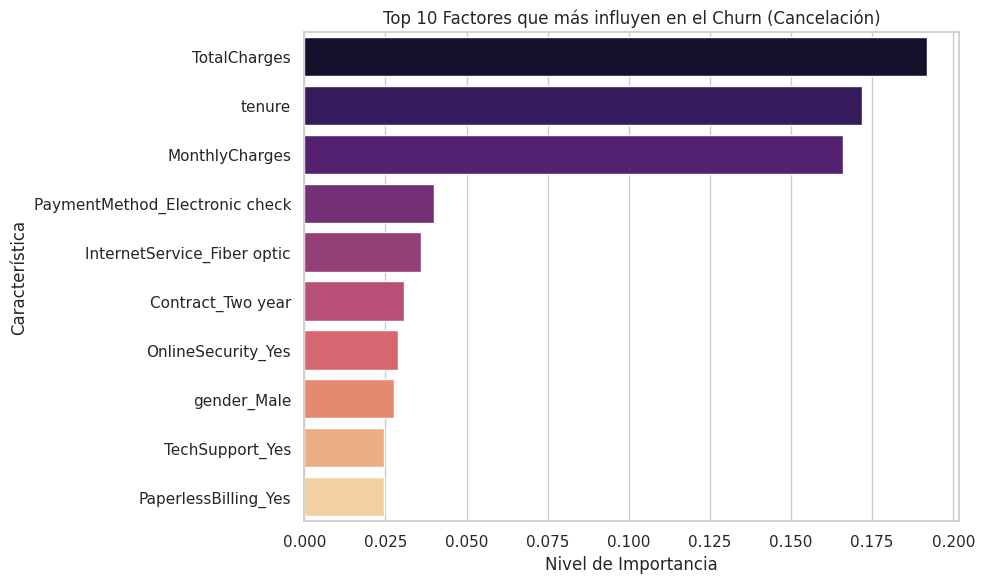

In [8]:
# Extraer la importancia de las variables del Random Forest
importancias = modelo_rf.feature_importances_
nombres_features = X_train.columns

# Crear un DataFrame para ordenar y graficar
df_importancias = pd.DataFrame({'Variable': nombres_features, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False).head(10) # Top 10

# Crear el gráfico visual
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='magma')
plt.title('Top 10 Factores que más influyen en el Churn (Cancelación)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

## **Conclusión Estratégica: Factores de Cancelación en Telecom X**
Basado en la importancia de variables extraída del modelo predictivo (Random Forest), hemos identificado los siguientes factores críticos que impulsan la cancelación (Churn) de nuestros clientes:

El impacto económico es el factor decisivo (Top 1 y 2): Las variables TotalCharges (Cargos Totales) y MonthlyCharges (Cargos Mensuales) son, por mucho, los indicadores más fuertes. Los clientes son altamente sensibles al precio. Facturas mensuales altas o la acumulación de un costo total elevado generan una fricción que termina en la cancelación del servicio.

La lealtad requiere tiempo (tenure - Top 3):
La antigüedad del cliente es el tercer factor más importante. Esto indica que el mayor riesgo de abandono ocurre en las primeras etapas del ciclo de vida del cliente. Si logramos retenerlos los primeros meses, la probabilidad de fuga disminuye drásticamente.

El peligro de la flexibilidad (Contract_Month-to-month - Top 4):
Los contratos de "mes a mes" facilitan la salida. Al no tener una penalización o compromiso a largo plazo (como los contratos de 1 o 2 años), los clientes abandonan el servicio ante cualquier inconveniente o mejor oferta de la competencia.

Métodos de pago manuales (PaymentMethod_Electronic check - Top 5):
Los clientes que pagan mediante cheque electrónico tienden a cancelar más. A menudo, los métodos que requieren acción mensual por parte del cliente generan más desconexiones (por olvido o por ver el gasto mes a mes) en comparación con los débitos automáticos a tarjetas de crédito.

Tipo de tecnología (InternetService_Fiber optic - Top 6):
Resulta interesante que tener fibra óptica aparezca en el top 6. Esto podría sugerir dos cosas: o el servicio de fibra óptica es considerablemente más caro y empuja los MonthlyCharges hacia arriba, o hay problemas de estabilidad en la red de fibra que están frustrando a los usuarios.

Recomendaciones de Acción para el Negocio:

Crear campañas de fidelización tempranas: Enfocarse en los nuevos clientes (tenure bajo) ofreciendo un servicio de atención al cliente premium durante sus primeros 3 a 6 meses.

Incentivar la migración de contratos: Ofrecer descuentos en MonthlyCharges a los clientes que están "mes a mes" si deciden pasarse a un contrato anual. Esto ataca directamente tres de las principales causas de abandono al mismo tiempo.

Promover el débito automático: Brindar pequeños beneficios o descuentos a quienes cambien su método de pago de cheque electrónico a tarjeta de crédito o transferencias automáticas.